# 1. Introduction
---

**Academic success is a key factor in shaping students’ futures, influencing career opportunities and societal progress. Yet, many institutions face challenges such as high dropout rates and difficulty in identifying at-risk students early. This project aims to predict academic outcomes—Dropout, Enrolled, or Graduate—using demographic, academic, and socioeconomic features. By applying machine learning models, we seek to uncover patterns that impact student performance and retention. The motivation is to support universities in making data-driven decisions, enabling proactive interventions that reduce dropout rates, improve resource allocation, and foster student achievement through timely guidance and personalized academic support.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/academic_success_dataset.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Dataset Description

In [ ]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (4424, 27)


In [ ]:
# Column names
print("\nColumns in dataset:")
for col in df.columns:
    print(col)



Columns in dataset:
Marital status
Application mode
Application order
Course
Daytime/evening attendance	
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
Unemployment rate
Inflation rate
GDP
Target
Unnamed: 25
Unnamed: 26


In [ ]:
# Data types and non-null counts
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4001 non-null   float64
 1   Application mode                3941 non-null   float64
 2   Application order               3998 non-null   float64
 3   Course                          3959 non-null   float64
 4   Daytime/evening attendance	     3984 non-null   float64
 5   Previous qualification          3990 non-null   float64
 6   Previous qualification (grade)  3952 non-null   float64
 7   Nacionality                     3978 non-null   float64
 8   Mother's qualification          4010 non-null   float64
 9   Father's qualification          3974 non-null   float64
 10  Mother's occupation             3988 non-null   float64
 11  Father's occupation             3999 non-null   float64
 12  Admission grade    

In [ ]:
# First few rows
print("\nFirst 10 rows:")
display(df.head(10))


First 10 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,...,1.0,0.0,NaN,0.0,10.8,1.4,1.74,Dropout,NaN,NaN
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,...,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,Graduate,NaN,NaN
2,1.0,NaN,5.0,9070.0,1.0,1.0,122.0,NaN,37.0,37.0,...,1.0,NaN,19.0,0.0,10.8,1.4,1.74,Dropout,NaN,NaN
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,NaN,0.0,20.0,0.0,9.4,-0.8,-3.12,Graduate,NaN,NaN
4,2.0,39.0,1.0,8014.0,0.0,1.0,100.0,1.0,37.0,NaN,...,0.0,0.0,NaN,0.0,13.9,-0.3,0.79,Graduate,NaN,NaN
5,2.0,39.0,1.0,9991.0,0.0,19.0,133.1,1.0,37.0,37.0,...,1.0,0.0,50.0,NaN,16.2,0.3,-0.92,Graduate,NaN,NaN
6,1.0,1.0,NaN,9500.0,1.0,1.0,142.0,1.0,19.0,38.0,...,0.0,NaN,18.0,0.0,15.5,2.8,-4.06,Graduate,NaN,NaN
7,1.0,NaN,4.0,9254.0,1.0,1.0,119.0,1.0,37.0,37.0,...,1.0,0.0,22.0,NaN,15.5,2.8,-4.06,Dropout,NaN,NaN
8,NaN,1.0,3.0,9238.0,NaN,1.0,137.0,62.0,1.0,1.0,...,0.0,1.0,21.0,1.0,16.2,0.3,-0.92,NaN,NaN,NaN
9,1.0,1.0,1.0,9238.0,1.0,NaN,138.0,1.0,1.0,19.0,...,0.0,0.0,18.0,0.0,8.9,NaN,3.51,Dropout,NaN,NaN


In [ ]:
# Target column distribution (assuming 'Target' is the output variable)
if "Target" in df.columns:
    print("\nTarget value counts:")
    print(df["Target"].value_counts())


Target value counts:
Target
Graduate    1979
Dropout     1273
Enrolled     719
Name: count, dtype: int64


# Clean column names & drop empty/unnamed columns

In [ ]:
def clean_columns(df):
    new_cols = []
    for c in df.columns:
        c2 = str(c).strip().replace("\t", " ").replace("\n", " ")
        c2 = "_".join([p for p in c2.split(" ") if p])  # collapse spaces to _
        new_cols.append(c2)
    df.columns = new_cols
    return df

df = clean_columns(df)

# drop fully empty and 'Unnamed' columns
empty_cols = [c for c in df.columns if df[c].isna().all()]
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
to_drop = list(set(empty_cols + unnamed_cols))
if to_drop:
    df = df.drop(columns=to_drop)

print("Shape (rows, cols):", df.shape)

print("\nColumns in dataset:")
for i, c in enumerate(df.columns, 1):
    print(f"{i}. {c}")


Shape (rows, cols): (4424, 25)

Columns in dataset:
1. Marital_status
2. Application_mode
3. Application_order
4. Course
5. Daytime/evening_attendance
6. Previous_qualification
7. Previous_qualification_(grade)
8. Nacionality
9. Mother's_qualification
10. Father's_qualification
11. Mother's_occupation
12. Father's_occupation
13. Admission_grade
14. Displaced
15. Educational_special_needs
16. Debtor
17. Tuition_fees_up_to_date
18. Gender
19. Scholarship_holder
20. Age_at_enrollment
21. International
22. Unemployment_rate
23. Inflation_rate
24. GDP
25. Target


# Dataset description answers

In [ ]:

# 1) Target column guess
target_col = "Target" if "Target" in df.columns else df.columns[-1]
print("target column:", target_col)


target column: Target


In [ ]:
# 2) How many features?
n_features = df.shape[1] - 1
print("How many features? ->", n_features)

How many features? -> 24


In [ ]:
# 3) Classification or regression? Why?
is_classification = (df[target_col].dtype == "object") or (df[target_col].nunique() <= 20)
print("Problem type:", "Classification" if is_classification else "Regression")
print("Reason: dtype =", df[target_col].dtype, "| unique values =", df[target_col].nunique())

Problem type: Classification
Reason: dtype = object | unique values = 3


In [ ]:
# 4) How many data points?
print("How many data points? ->", len(df))

How many data points? -> 4424


In [ ]:
# 5) What kind of features (Quantitative / Categorical)?
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]
if target_col in categorical_cols: categorical_cols.remove(target_col)
if target_col in numeric_cols: numeric_cols.remove(target_col)

print("\nNumerical features:", len(numeric_cols))
for c in numeric_cols: print(" -", c)

print("\nCategorical features:", len(categorical_cols))
for c in categorical_cols: print(" -", c)

print("\nDo we need to encode categoricals?")
print("Yes — ML models require numeric inputs; categorical features must be encoded.")


Numerical features: 24
 - Marital_status
 - Application_mode
 - Application_order
 - Course
 - Daytime/evening_attendance
 - Previous_qualification
 - Previous_qualification_(grade)
 - Nacionality
 - Mother's_qualification
 - Father's_qualification
 - Mother's_occupation
 - Father's_occupation
 - Admission_grade
 - Displaced
 - Educational_special_needs
 - Debtor
 - Tuition_fees_up_to_date
 - Gender
 - Scholarship_holder
 - Age_at_enrollment
 - International
 - Unemployment_rate
 - Inflation_rate
 - GDP

Categorical features: 0

Do we need to encode categoricals?
Yes — ML models require numeric inputs; categorical features must be encoded.


# Correlation of all features (incl. target) + heatmap

Red values represent positive correlation (stronger similarity between two features).

Blue values represent negative correlation (one feature increases while the other decreases).

Lighter colors represent weaker correlations.

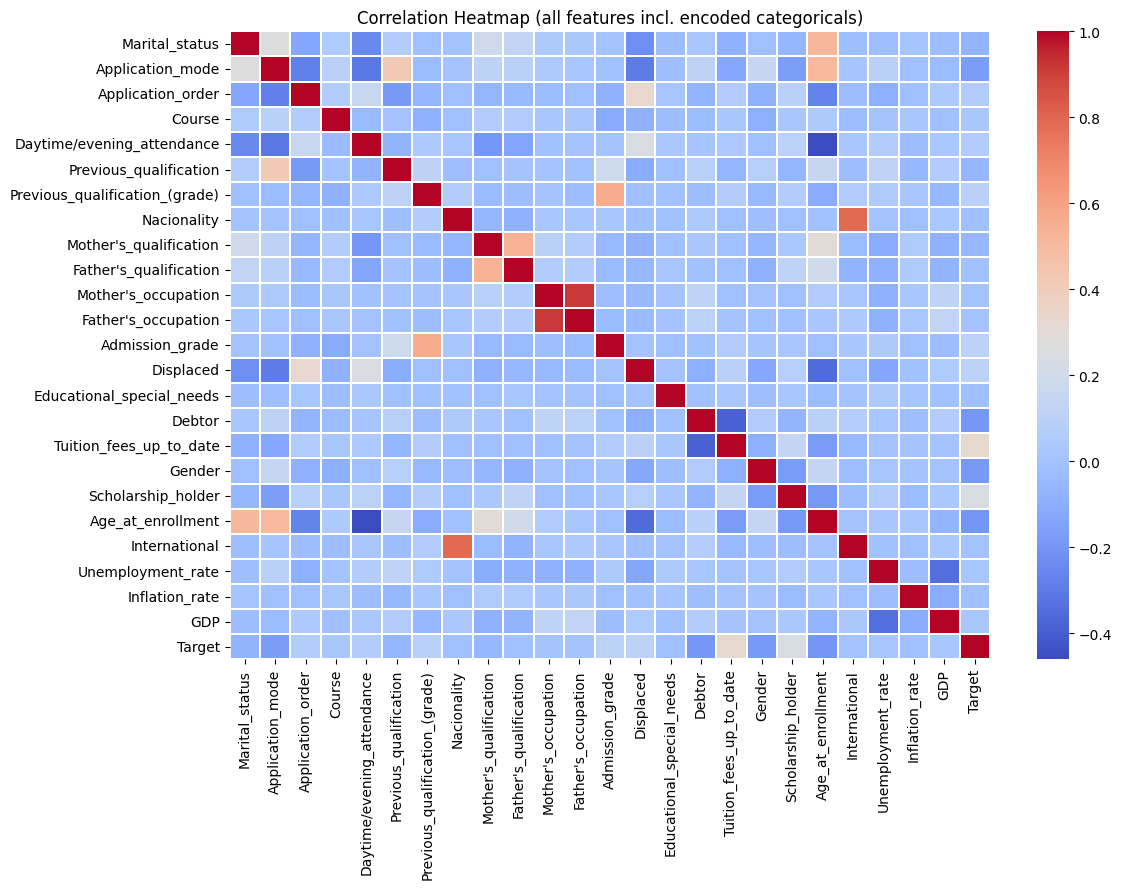

In [ ]:

# Encode object columns temporarily for correlation
df_corr = df.copy()
obj_cols = df_corr.select_dtypes(include=["object"]).columns.tolist()
if obj_cols:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    df_corr[obj_cols] = enc.fit_transform(df_corr[obj_cols].astype(str))

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.3)
plt.title("Correlation Heatmap (all features incl. encoded categoricals)")
plt.tight_layout()
plt.show()




In [ ]:
# What do we understand after correlation? -> show top absolute correlations with target
if target_col in corr.columns:
    target_abs = corr[target_col].drop(labels=[target_col]).abs().sort_values(ascending=False)
    print("Top |correlation| with target:")
    display(target_abs.head(10))


Top |correlation| with target:


,Target
Tuition_fees_up_to_date,0.326369
Scholarship_holder,0.238014
Age_at_enrollment,0.199984
Debtor,0.194212
Gender,0.182109
Application_mode,0.171599
Displaced,0.100348
Admission_grade,0.098912
Previous_qualification_(grade),0.087157
Marital_status,0.073431


# Imbalanced Dataset check (bar chart of classes)

Class counts:
 Target
Graduate    1979
Dropout     1273
Enrolled     719
NaN          453
Name: count, dtype: int64

Class proportions:
 Target
Graduate    0.4473
Dropout     0.2877
Enrolled    0.1625
NaN         0.1024
Name: count, dtype: float64


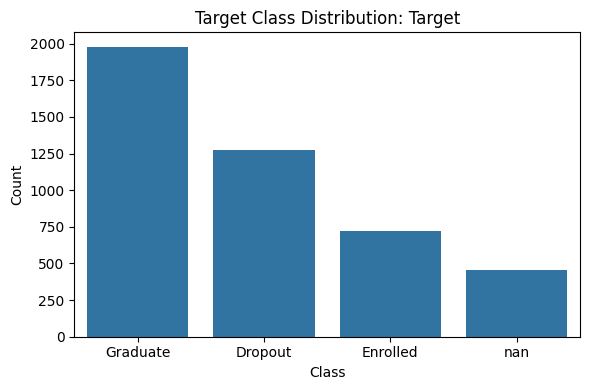

In [ ]:

if is_classification:
    class_counts = df[target_col].value_counts(dropna=False)
    print("Class counts:\n", class_counts)
    print("\nClass proportions:\n", (class_counts / len(df)).round(4))

    plt.figure(figsize=(6,4))
    sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
    plt.title(f"Target Class Distribution: {target_col}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Regression problem: class imbalance chart not applicable.")


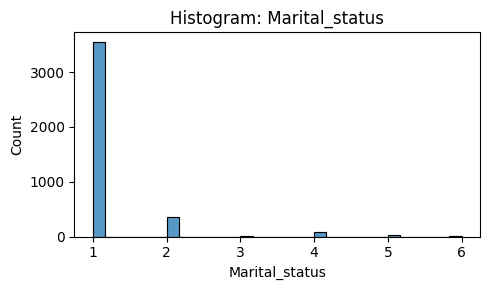

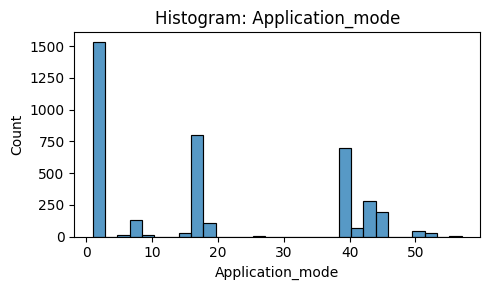

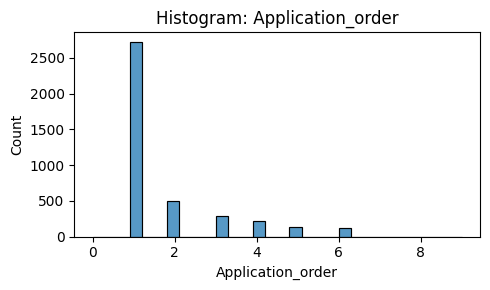

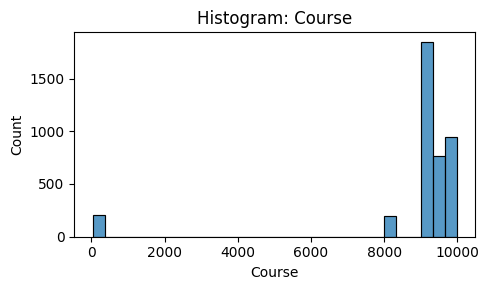

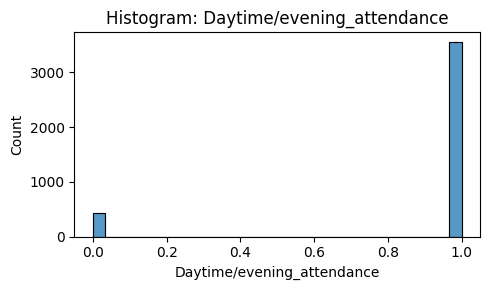

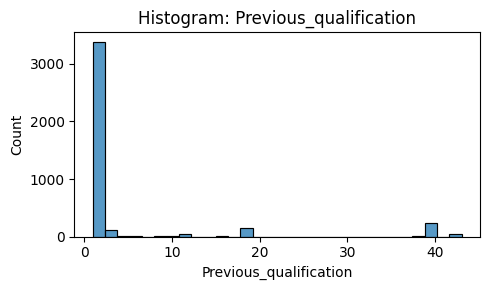

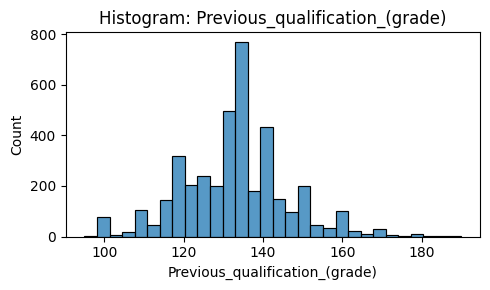

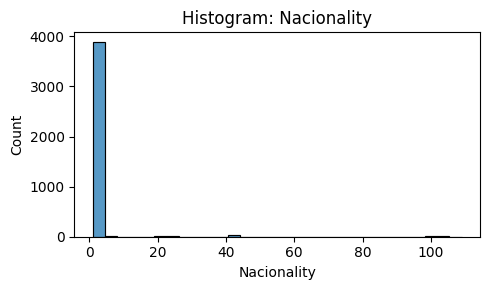

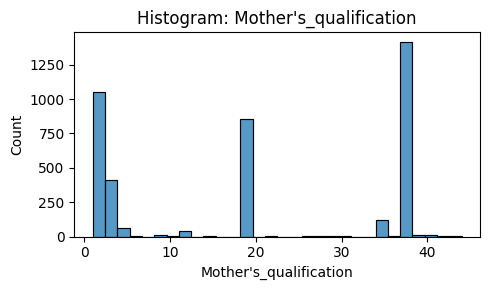

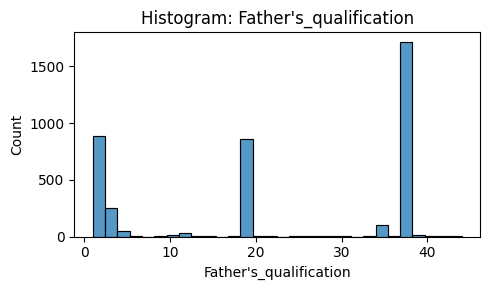

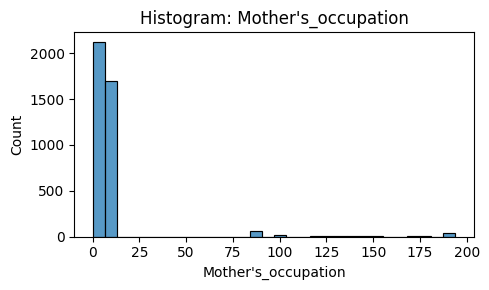

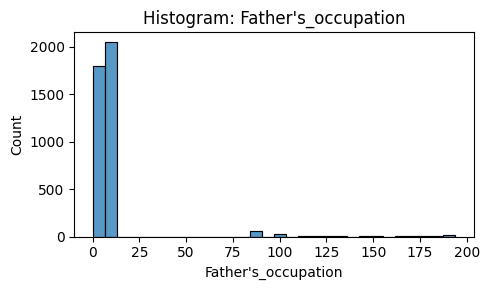

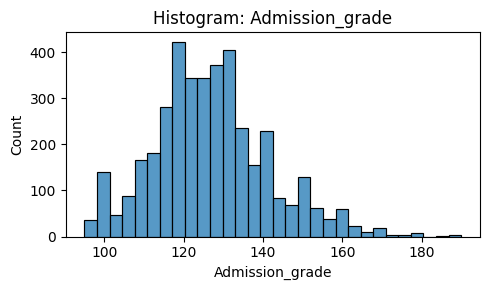

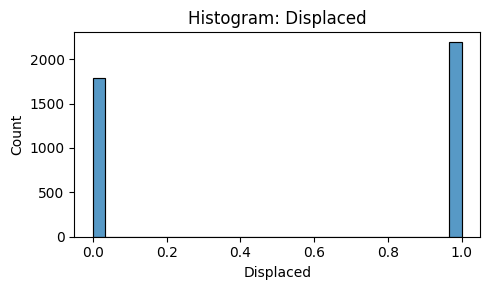

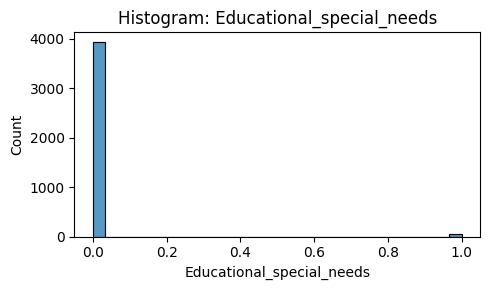

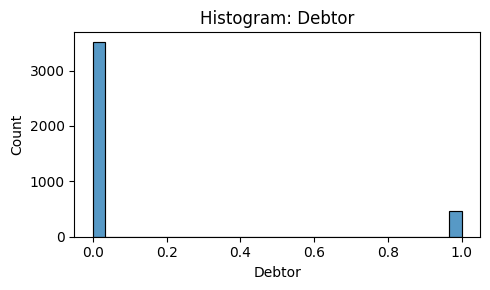

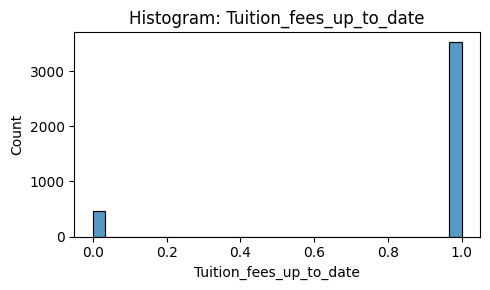

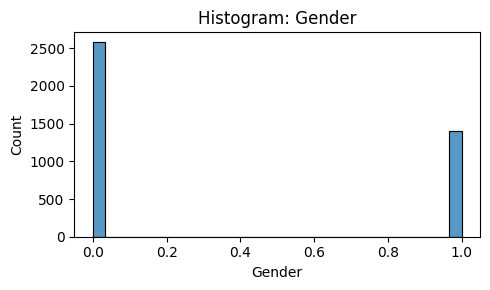

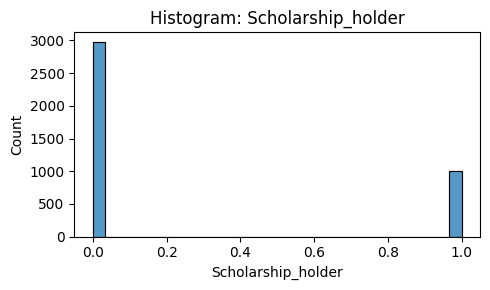

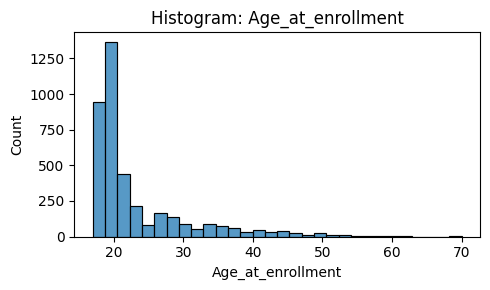

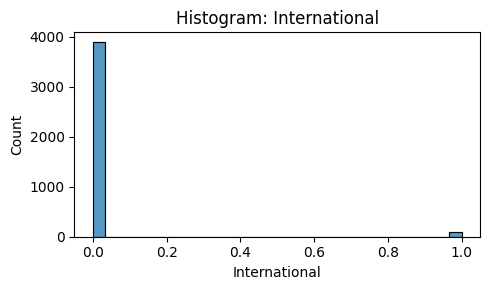

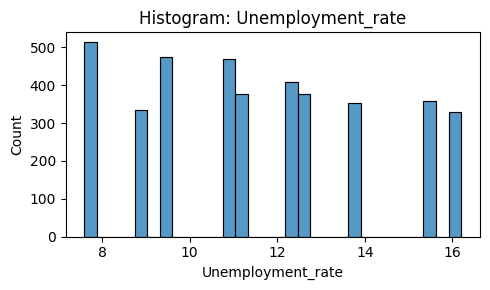

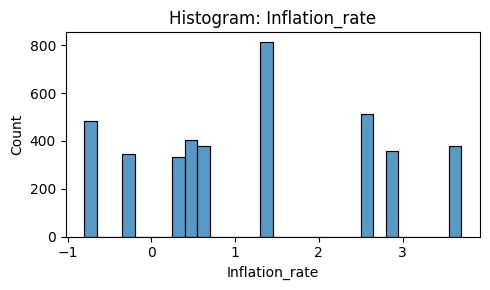

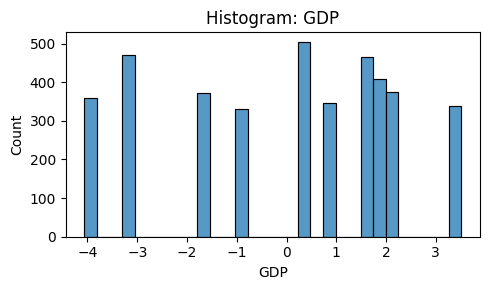

In [ ]:

#(a few useful plots)


# Histograms for up to 10 numeric features
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f"Histogram: {col}")
    plt.tight_layout()
    plt.show()





#3. Dataset pre-processing

In [ ]:
print("\nMissing values before preprocessing:")
print(df.isnull().sum())


Missing values before preprocessing:
Marital_status                    423
Application_mode                  483
Application_order                 426
Course                            465
Daytime/evening_attendance        440
Previous_qualification            434
Previous_qualification_(grade)    472
Nacionality                       446
Mother's_qualification            414
Father's_qualification            450
Mother's_occupation               436
Father's_occupation               425
Admission_grade                   462
Displaced                         442
Educational_special_needs         448
Debtor                            452
Tuition_fees_up_to_date           426
Gender                            437
Scholarship_holder                450
Age_at_enrollment                 444
International                     428
Unemployment_rate                 429
Inflation_rate                    422
GDP                               456
Target                            453
dtype: int64

In [ ]:
# Remove rows where target column has missing values
df = df.dropna(subset=[target_col])

In [ ]:

# Impute missing values in numerical features (median)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
# Impute missing values in categorical features (mode)
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Check if there are any missing values left
print("\nMissing values after preprocessing:")
print(df.isnull().sum())


Missing values after preprocessing:
Marital_status                    0
Application_mode                  0
Application_order                 0
Course                            0
Daytime/evening_attendance        0
Previous_qualification            0
Previous_qualification_(grade)    0
Nacionality                       0
Mother's_qualification            0
Father's_qualification            0
Mother's_occupation               0
Father's_occupation               0
Admission_grade                   0
Displaced                         0
Educational_special_needs         0
Debtor                            0
Tuition_fees_up_to_date           0
Gender                            0
Scholarship_holder                0
Age_at_enrollment                 0
International                     0
Unemployment_rate                 0
Inflation_rate                    0
GDP                               0
Target                            0
dtype: int64


In [ ]:
print("Shape of dataset:", df.shape)

Shape of dataset: (3971, 25)


# Handling Categorical Values through Encoding

**Encoding**

Converts categorical columns into numeric values using one-hot encoding, which is necessary for machine learning models

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Show first few rows after encoding
print("\nEncoded Data (first few rows):")
df_encoded.head(10)


Encoded Data (first few rows):


,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Unemployment_rate,Inflation_rate,GDP,Target_Enrolled,Target_Graduate
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,...,1.0,1.0,0.0,20.0,0.0,10.8,1.4,1.74,False,False
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,...,0.0,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,False,True
2,1.0,17.0,5.0,9070.0,1.0,1.0,122.0,1.0,37.0,37.0,...,0.0,1.0,0.0,19.0,0.0,10.8,1.4,1.74,False,False
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,1.0,0.0,0.0,20.0,0.0,9.4,-0.8,-3.12,False,True
4,2.0,39.0,1.0,8014.0,0.0,1.0,100.0,1.0,37.0,19.0,...,1.0,0.0,0.0,20.0,0.0,13.9,-0.3,0.79,False,True
5,2.0,39.0,1.0,9991.0,0.0,19.0,133.1,1.0,37.0,37.0,...,1.0,1.0,0.0,50.0,0.0,16.2,0.3,-0.92,False,True
6,1.0,1.0,1.0,9500.0,1.0,1.0,142.0,1.0,19.0,38.0,...,1.0,0.0,0.0,18.0,0.0,15.5,2.8,-4.06,False,True
7,1.0,17.0,4.0,9254.0,1.0,1.0,119.0,1.0,37.0,37.0,...,0.0,1.0,0.0,22.0,0.0,15.5,2.8,-4.06,False,False
9,1.0,1.0,1.0,9238.0,1.0,1.0,138.0,1.0,1.0,19.0,...,0.0,0.0,0.0,18.0,0.0,8.9,1.4,3.51,False,False
10,1.0,1.0,1.0,9670.0,1.0,1.0,139.0,1.0,38.0,19.0,...,1.0,0.0,0.0,18.0,0.0,13.9,1.4,0.79,False,True


# Feature Scaling

Ensures Fair Weighting Across Features

Feature scaling ensures fair representation, improved efficiency, and numerical stability, enabling the machine learning model to perform optimally

**Standard Scaler:**

$$\frac{X - mean}{\sigma}$$
where,
$$\sigma = standard \space deviation $$

**Why we use it ?**

-- There are assumed to be no or minimal extreme outliers in this dataset

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply standardization to numerical columns
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Show first few rows after scaling
print("\nScaled Data (first few rows):")
df_encoded.head()



Scaled Data (first few rows):


,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Unemployment_rate,Inflation_rate,GDP,Target_Enrolled,Target_Graduate
0,-0.282413,-0.082378,2.633881,-4.502352,0.328603,-0.330439,-0.851997,-0.115624,-0.033872,-0.678159,...,0.344829,1.466829,-0.540576,-0.400249,-0.15571,-0.286028,0.119120,0.776856,False,False
1,-0.282413,-0.203513,-0.522881,0.180734,0.328603,-0.330439,2.173780,-0.115624,-1.244406,-1.294792,...,-2.899992,1.466829,-0.540576,-0.536724,-0.15571,0.940599,-1.174132,0.336525,False,True
2,-0.282413,-0.082378,2.633881,0.085866,0.328603,-0.330439,-0.851997,-0.115624,1.176663,1.034708,...,-2.899992,1.466829,-0.540576,-0.536724,-0.15571,-0.286028,0.119120,0.776856,False,False
3,-0.282413,-0.082378,0.266310,0.448325,0.328603,-0.330439,-0.851997,-0.115624,1.243914,1.034708,...,0.344829,-0.681743,-0.540576,-0.400249,-0.15571,-0.839988,-1.554500,-1.475785,False,True
4,1.509058,1.250103,-0.522881,-0.458595,-3.043186,-0.330439,-2.603762,-0.115624,1.176663,-0.198556,...,0.344829,-0.681743,-0.540576,-0.400249,-0.15571,0.940599,-1.174132,0.336525,False,True


#4. DATASET SPLITTING

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
target_col = "Target" if "Target" in df.columns else df.columns[-1]
# Keep only rows with a known target
data = df.dropna(subset=[target_col]).copy()

In [ ]:
# Split into features and target
features = data.drop(columns=[target_col])
target   = data[target_col]

In [ ]:
# 70/30 split (set TEST_SIZE=0.2 for 80/20)
TEST_SIZE = 0.30
RANDOM_STATE = 42    #random state = 42 , helps us to train/test spliting static , no change on different running the code

In [ ]:
# Stratify if classification (categorical or few unique classes)
is_classification = (target.dtype == "object") or (target.nunique() <= 20)
stratify_arg = target if is_classification else None

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_arg  # uses stratified split only when classification
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2779, 24)
X_test : (1192, 24)


In [ ]:
# Reshape y_train and y_test to (n_samples, 1)
y_train = y_train.values.reshape(-1, 1)  # Reshape for 2D
y_test = y_test.values.reshape(-1, 1)

# Check the new shape
print("y_train shape after reshape:", y_train.shape)
print("y_test shape after reshape:", y_test.shape)


y_train shape after reshape: (2779, 1)
y_test shape after reshape: (1192, 1)


In [ ]:
pd.DataFrame(X_train).head()

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Unemployment_rate,Inflation_rate,GDP
861,1.0,39.0,2.0,9147.0,1.0,1.0,133.1,1.0,19.0,38.0,...,0.0,1.0,0.0,1.0,0.0,28.0,0.0,9.4,-0.8,-3.12
4296,1.0,44.0,1.0,9070.0,1.0,39.0,120.0,1.0,1.0,38.0,...,1.0,0.0,1.0,1.0,1.0,21.0,0.0,12.4,1.4,1.79
1055,1.0,1.0,1.0,9500.0,1.0,1.0,118.0,1.0,19.0,19.0,...,0.0,0.0,1.0,0.0,1.0,19.0,0.0,12.4,0.5,1.79
803,1.0,1.0,1.0,9773.0,1.0,1.0,141.0,1.0,38.0,38.0,...,0.0,0.0,1.0,0.0,0.0,18.0,0.0,11.1,0.6,2.02
97,1.0,1.0,5.0,9500.0,1.0,1.0,132.0,1.0,37.0,19.0,...,0.0,0.0,1.0,0.0,1.0,18.0,0.0,12.4,0.5,1.79


In [ ]:
pd.DataFrame(X_test).head()

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Unemployment_rate,Inflation_rate,GDP
1910,1.0,1.0,2.0,9238.0,1.0,1.0,120.0,1.0,3.0,19.0,...,0.0,0.0,1.0,0.0,0.0,20.0,0.0,11.1,-0.3,0.79
1989,1.0,1.0,5.0,9670.0,1.0,1.0,120.0,1.0,4.0,1.0,...,0.0,0.0,1.0,0.0,0.0,18.0,0.0,8.9,1.4,3.51
4184,1.0,1.0,1.0,9238.0,1.0,1.0,136.0,1.0,38.0,38.0,...,0.0,0.0,1.0,0.0,0.0,19.0,0.0,7.6,2.6,0.32
2663,1.0,39.0,1.0,9991.0,0.0,1.0,120.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,38.0,0.0,8.9,1.4,3.51
1195,1.0,17.0,1.0,9853.0,1.0,1.0,125.0,1.0,19.0,19.0,...,0.0,0.0,1.0,0.0,0.0,18.0,0.0,11.1,-0.3,0.79


In [ ]:
pd.DataFrame(y_train).head()

,0
0,Dropout
1,Graduate
2,Graduate
3,Graduate
4,Graduate


In [ ]:
pd.DataFrame(y_test).head()

,0
0,Graduate
1,Enrolled
2,Graduate
3,Dropout
4,Enrolled


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


#KNN

In [ ]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy}")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.5184563758389261
              precision    recall  f1-score   support

     Dropout       0.46      0.51      0.48       382
    Enrolled       0.26      0.17      0.20       216
    Graduate       0.62      0.65      0.64       594

    accuracy                           0.52      1192
   macro avg       0.44      0.44      0.44      1192
weighted avg       0.50      0.52      0.51      1192



/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


#decision Tree

In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy}")
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.5201342281879194
              precision    recall  f1-score   support

     Dropout       0.51      0.49      0.50       382
    Enrolled       0.24      0.23      0.24       216
    Graduate       0.62      0.65      0.63       594

    accuracy                           0.52      1192
   macro avg       0.46      0.45      0.45      1192
weighted avg       0.51      0.52      0.52      1192



#Logistic Regression

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(classification_report(y_test, y_pred_lr))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Logistic Regression Accuracy: 0.5545302013422819
              precision    recall  f1-score   support

     Dropout       0.55      0.40      0.46       382
    Enrolled       0.28      0.02      0.04       216
    Graduate       0.56      0.85      0.68       594

    accuracy                           0.55      1192
   macro avg       0.46      0.42      0.39      1192
weighted avg       0.51      0.55      0.49      1192



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Naive Bayes Classifier
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy}")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.5629194630872483
              precision    recall  f1-score   support

     Dropout       0.58      0.47      0.52       382
    Enrolled       0.19      0.06      0.10       216
    Graduate       0.59      0.80      0.68       594

    accuracy                           0.56      1192
   macro avg       0.45      0.45      0.43      1192
weighted avg       0.51      0.56      0.52      1192



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Neural Network (MLP Classifier)
nn_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)

# Train the model
nn_model.fit(X_train, y_train)

# Predictions
y_pred_nn = nn_model.predict(X_test)

# Evaluate the model
nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"Neural Network Accuracy: {nn_accuracy}")
print(classification_report(y_test, y_pred_nn))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Neural Network Accuracy: 0.4941275167785235
              precision    recall  f1-score   support

     Dropout       0.69      0.02      0.05       382
    Enrolled       0.23      0.06      0.10       216
    Graduate       0.51      0.95      0.66       594

    accuracy                           0.49      1192
   macro avg       0.47      0.35      0.27      1192
weighted avg       0.52      0.49      0.36      1192



KMeans ARI Score: -0.0001689680717459278


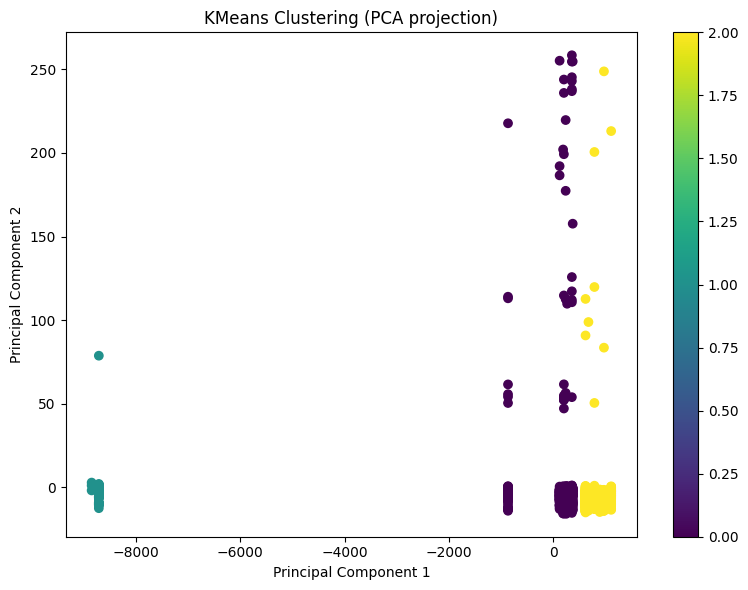

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Apply KMeans for Clustering
# ==========================
num_clusters = len(np.unique(y_train))  # Number of clusters = number of unique target values

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_train)

# Predictions (clusters) for the test set
y_pred_kmeans = kmeans.predict(X_test)

# ==========================
# Evaluate Clustering using Adjusted Rand Index (ARI)
# ==========================
y_test_flat = y_test.ravel()  # Flattening y_test (1D array)
y_pred_kmeans_flat = y_pred_kmeans.ravel()  # Flattening predicted clusters

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_test_flat, y_pred_kmeans_flat)
print(f"KMeans ARI Score: {ari}")

# ==========================
# Visualizing Clusters with PCA (2D Projection)
# ==========================
# Apply PCA on X_test for visualization
pca = PCA(n_components=2)
X_2D_test = pca.fit_transform(X_test)

# Plot the clusters on the 2D PCA projection
plt.figure(figsize=(8, 6))
plt.scatter(X_2D_test[:, 0], X_2D_test[:, 1], c=y_pred_kmeans_flat, cmap='viridis')
plt.title("KMeans Clustering (PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.tight_layout()
plt.show()


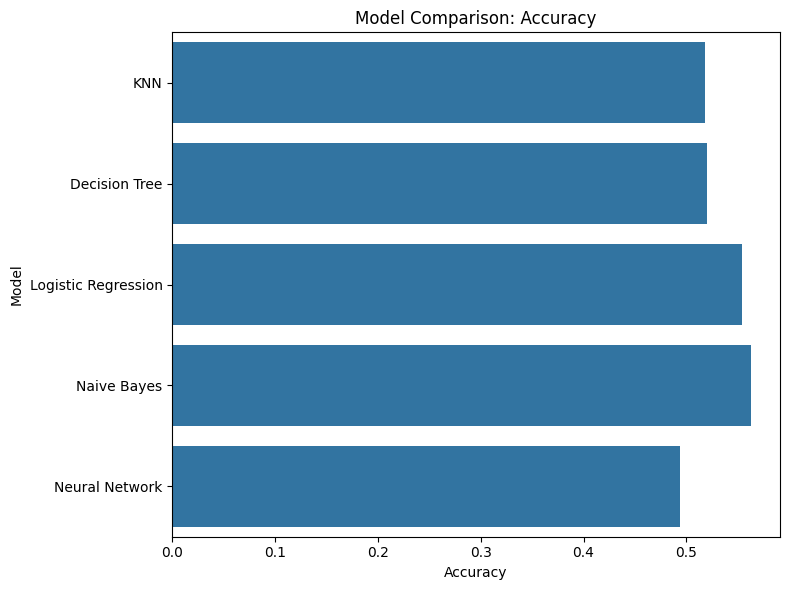

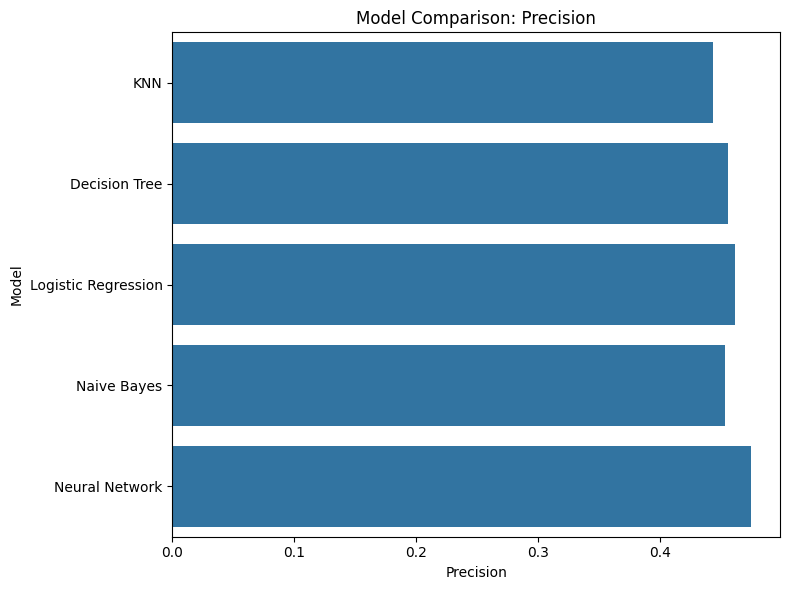

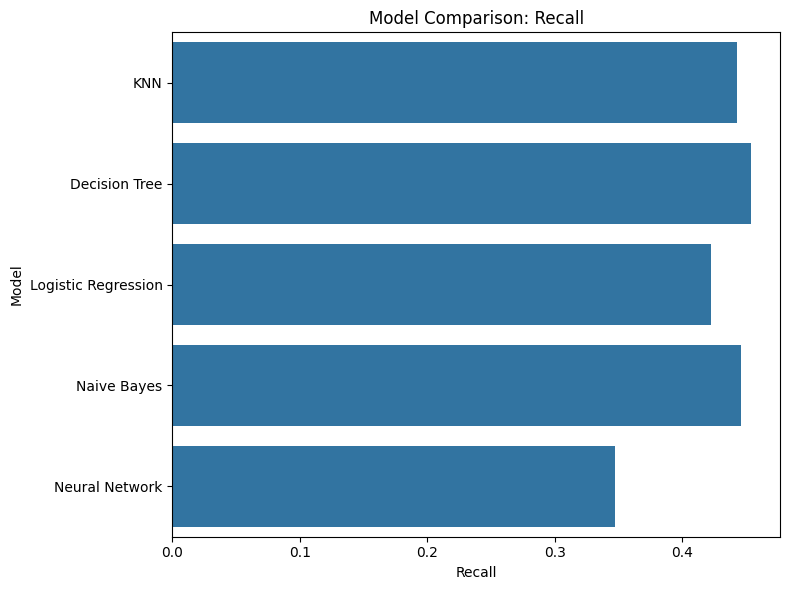

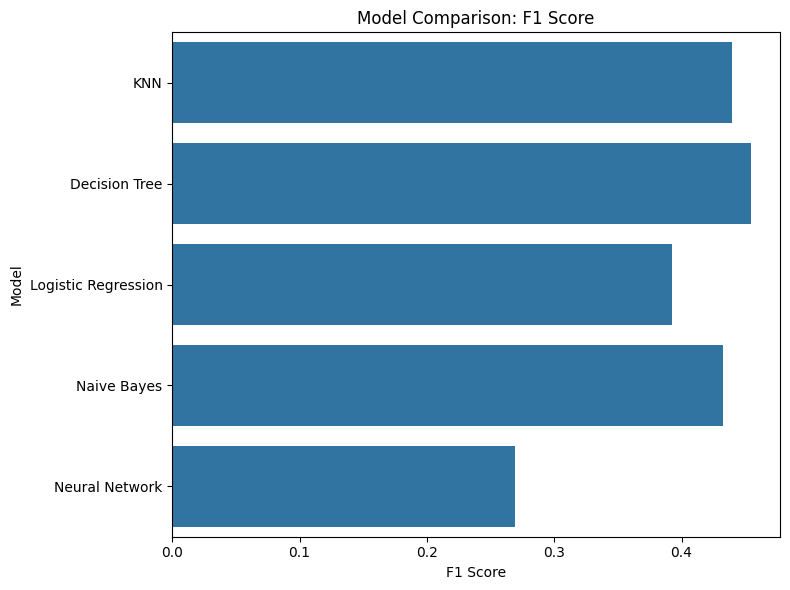

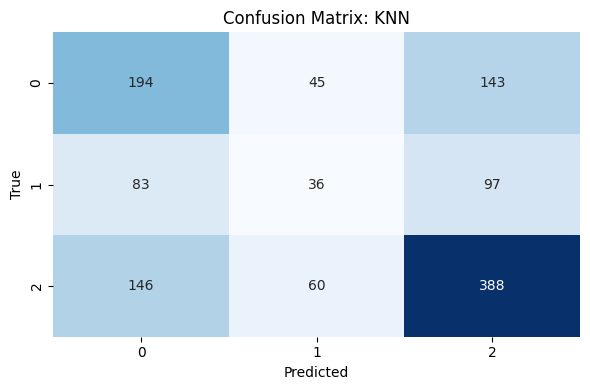

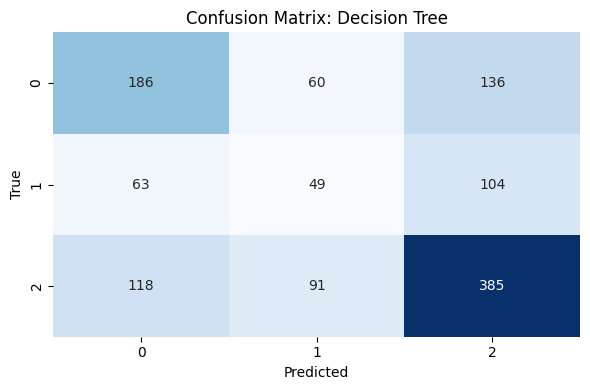

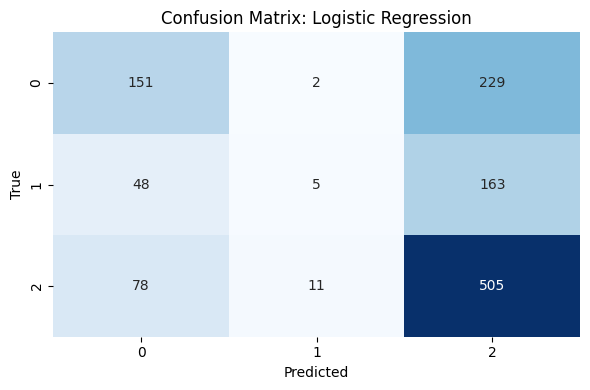

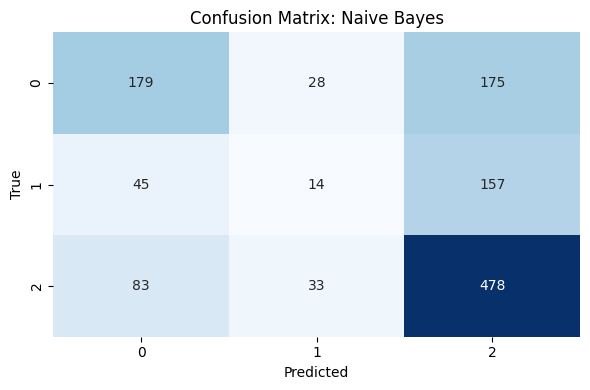

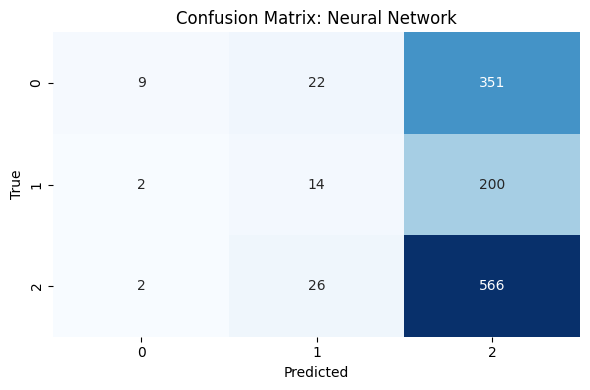

,Model,Accuracy,Precision,Recall,F1 Score,AUC,R2 Score,Loss,Confusion Matrix,ROC Curve
0,KNN,0.518456,0.443927,0.442573,0.439564,0.625563,None,None,"[[194, 45, 143], [83, 36, 97], [146, 60, 388]]",None
1,Decision Tree,0.520134,0.455937,0.453970,0.454635,0.597067,None,None,"[[186, 60, 136], [63, 49, 104], [118, 91, 385]]",None
2,Logistic Regression,0.554530,0.461964,0.422868,0.392801,0.654366,None,None,"[[151, 2, 229], [48, 5, 163], [78, 11, 505]]",None
3,Naive Bayes,0.562919,0.453284,0.446038,0.432242,0.685886,None,None,"[[179, 28, 175], [45, 14, 157], [83, 33, 478]]",None
4,Neural Network,0.494128,0.474943,0.347079,0.269297,0.540163,None,None,"[[9, 22, 351], [2, 14, 200], [2, 26, 566]]",None


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ==========================
# Store results for comparison
# ==========================
results = {
    'Model': ['KNN', 'Decision Tree', 'Logistic Regression', 'Naive Bayes', 'Neural Network'],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'AUC': [],
    'R2 Score': [],
    'Loss': [],
    'Confusion Matrix': [],
    'ROC Curve': []
}

# Models and predictions
models = {
    'KNN': knn_model,
    'Decision Tree': dt_model,
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'Neural Network': nn_model
}

# Flatten y_train and y_test to 1D arrays (for classification)
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# Store confusion matrices and ROC curves
conf_mats = {}

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)

    # 1. Accuracy
    accuracy = accuracy_score(y_test_flat, y_pred)
    results['Accuracy'].append(accuracy)

    # 2. Precision, Recall, F1-Score
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_flat, y_pred, average='macro', zero_division=0
    )
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test_flat, y_pred)
    conf_mats[name] = cm
    results['Confusion Matrix'].append(cm)   # ✅ keep same length

    # 4. AUC (classification only)
    if is_classification:
        if hasattr(model, "predict_proba"):
            try:
                auc_score = roc_auc_score(
                    y_test_flat, model.predict_proba(X_test),
                    multi_class="ovr", average="macro"
                )
                results['AUC'].append(auc_score)
            except Exception:
                results['AUC'].append(None)
        else:
            results['AUC'].append(None)
    else:
        results['AUC'].append(None)

    # 5. ROC Curve placeholder
    results['ROC Curve'].append(None)   # ✅ always append something

    # 6. R2 Score & Loss
    if not is_classification:
        r2 = r2_score(y_test_flat, y_pred)
        loss = mean_squared_error(y_test_flat, y_pred)
        results['R2 Score'].append(r2)
        results['Loss'].append(loss)
    else:
        results['R2 Score'].append(None)
        results['Loss'].append(None)

# ==========================
# Model Comparison Bar Charts
# ==========================
comparison_df = pd.DataFrame(results)

plt.figure(figsize=(8, 6))
sns.barplot(x='Accuracy', y='Model', data=comparison_df)
plt.title("Model Comparison: Accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='Precision', y='Model', data=comparison_df)
plt.title("Model Comparison: Precision")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='Recall', y='Model', data=comparison_df)
plt.title("Model Comparison: Recall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='F1 Score', y='Model', data=comparison_df)
plt.title("Model Comparison: F1 Score")
plt.tight_layout()
plt.show()

# ==========================
# Confusion Matrix for Each Model
# ==========================
for name, cm in conf_mats.items():
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ==========================
# Display Final Comparison Table
# ==========================
display(comparison_df)
